In [1]:
#Shastha Rekha B :)
#The flow of this project is explained through comments i hope the spider team enjoys it.
# CELL 1 - markdown note (make this a text cell in colab)
# Spider ML Task 1 - Base Task
# Fashion-MNIST Classification using a custom PyTorch neural network
#
# What I am doing here:
# I am building a neural network from scratch using PyTorch to classify
# clothing items from the Fashion-MNIST dataset. The model has a branching
# structure with skip connections and a concatenation layer, exactly as given
# in the task diagram.
#
# The pipeline goes like this:
# load data -> build model -> train -> validate -> plot results -> save -> predict
#
# Libraries used: PyTorch, NumPy, Pandas, Matplotlib, Pickle

In [2]:
# CELL 2 - imports

# standard stuff I need for everything
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

# pytorch is the main deep learning library I am using
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

# this helps me download Fashion-MNIST directly without doing it manually
import torchvision
import torchvision.transforms as transforms

In [3]:
# CELL 3 - set seeds so results are reproducible

# I am setting a seed so that random operations give the same result every time
# this is important for consistency when someone else runs my code
torch.manual_seed(42)
np.random.seed(42)

# check if a GPU is available, use it if yes, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
# CELL 4 - load and prepare the dataset

# Fashion-MNIST has 28x28 grayscale images of 10 clothing categories
# I am normalizing pixel values to have mean 0.5 and std 0.5
# this helps the model train faster and more stably

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# downloading the training set (60000 images)
full_train_data = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# downloading the test set (10000 images, no labels available)
test_data = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# splitting training data into train and validation sets
# I am using 80% for training and 20% for validation
train_size = int(0.8 * len(full_train_data))
val_size = len(full_train_data) - train_size
train_dataset, val_dataset = random_split(full_train_data, [train_size, val_size])

print("Training samples:", train_size)
print("Validation samples:", val_size)
print("Test samples:", len(test_data))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.31MB/s]

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [5]:
# CELL 5 - create data loaders

# DataLoader handles batching, shuffling, and feeding data to the model
# batch size of 64 means the model sees 64 images at a time before updating weights

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

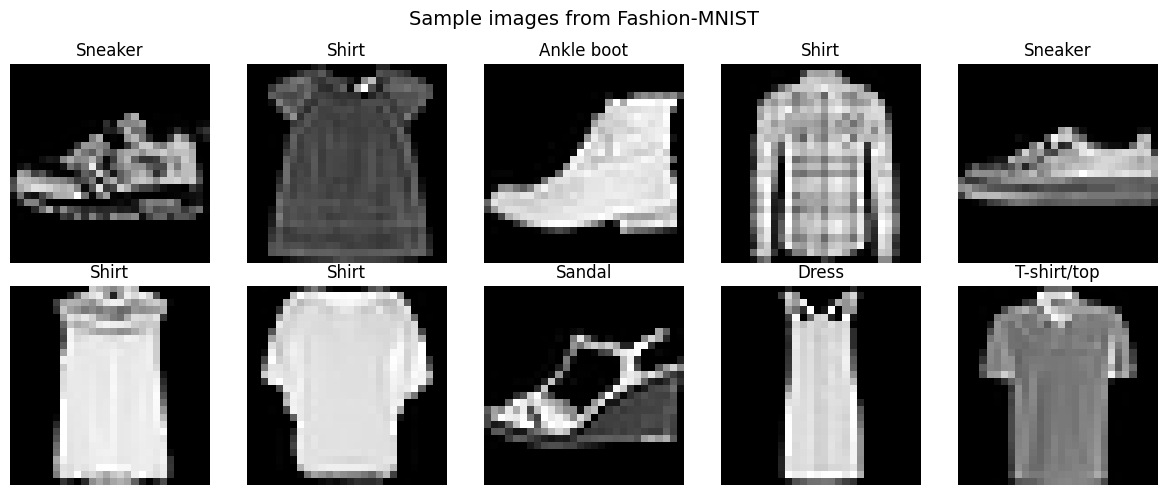

In [6]:
# CELL 6 - visualize a few training samples

# just checking what the data looks like before feeding it to the model
# Fashion-MNIST has 10 classes corresponding to clothing items

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# grab one batch and show the first 10 images
sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(class_names[sample_labels[i]])
    ax.axis('off')

plt.suptitle("Sample images from Fashion-MNIST", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# CELL 7 - define the neural network model

# this is the exact architecture from the task diagram
# here is what happens step by step:
#
# input (28x28) -> flatten to 784
# -> hidden layer down to 16 neurons
# then it splits into two branches:
#   branch A: 16 -> 8 -> 8
#   branch B: 16 -> 12 -> 8
# the branch A output is added to itself (skip connection)
# then branch A and branch B are concatenated to get 16
# -> output layer: 16 -> 10 classes
#
# skip connections help gradients flow during backprop and reduce vanishing gradient

class FashionNet(nn.Module):
    def __init__(self):
        super(FashionNet, self).__init__()

        # shared layers at the top
        self.flatten = nn.Flatten()
        self.input_layer = nn.Linear(784, 16)

        # branch A goes 16 -> 8 -> 8
        self.branch_a_layer1 = nn.Linear(16, 8)
        self.branch_a_layer2 = nn.Linear(8, 8)

        # branch B goes 16 -> 12 -> 8
        self.branch_b_layer1 = nn.Linear(16, 12)
        self.branch_b_layer2 = nn.Linear(12, 8)

        # final output after concatenating both branches (8+8=16) -> 10
        self.output_layer = nn.Linear(16, 10)

        # relu is my activation function, it just clips negatives to zero
        self.relu = nn.ReLU()

        # dropout helps prevent overfitting by randomly turning off neurons
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        # flatten the 28x28 image into a 784 length vector
        x = self.flatten(x)

        # pass through the first shared hidden layer
        x = self.relu(self.input_layer(x))

        # branch A
        branch_a = self.relu(self.branch_a_layer1(x))
        branch_a = self.dropout(branch_a)
        branch_a_out = self.relu(self.branch_a_layer2(branch_a))

        # skip connection: adding the first branch A output back to itself
        # this is the skip connection ADD from the diagram
        branch_a_skip = branch_a + branch_a_out

        # branch B
        branch_b = self.relu(self.branch_b_layer1(x))
        branch_b = self.dropout(branch_b)
        branch_b_out = self.relu(self.branch_b_layer2(branch_b))

        # concatenate both branches along the feature dimension
        # this gives us a 16-dimensional vector (8 from A + 8 from B)
        combined = torch.cat([branch_a_skip, branch_b_out], dim=1)

        # final classification layer, no activation here because
        # CrossEntropyLoss applies softmax internally
        out = self.output_layer(combined)
        return out


# create an instance of the model and move it to GPU if available
model = FashionNet().to(device)
print(model)

# count total parameters so I know how big the model is
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

FashionNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (input_layer): Linear(in_features=784, out_features=16, bias=True)
  (branch_a_layer1): Linear(in_features=16, out_features=8, bias=True)
  (branch_a_layer2): Linear(in_features=8, out_features=8, bias=True)
  (branch_b_layer1): Linear(in_features=16, out_features=12, bias=True)
  (branch_b_layer2): Linear(in_features=12, out_features=8, bias=True)
  (output_layer): Linear(in_features=16, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)
Total trainable parameters: 13246


In [12]:
# CELL 8 - define loss function and optimizer

# CrossEntropyLoss is the standard choice for multi-class classification
# it combines LogSoftmax and NLLLoss in one go

loss_function = nn.CrossEntropyLoss()

# Adam optimizer handles learning rate adaptation automatically
# it generally works better than plain SGD for tasks like this
# lr=0.001 is a good default starting point
optimizer = optim.Adam(model.parameters(), lr=0.001)

# I am also using a learning rate scheduler
# it reduces the learning rate by half if validation loss stops improving
# this helps the model fine-tune itself in later epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [13]:
# CELL 9 - training and validation loop

# num_epochs is how many times the model sees the full training set
num_epochs = 30

# I will store these to plot later
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

# for saving the best model during training
best_val_accuracy = 0.0
best_model_weights = None

print("Starting training...\n")

for epoch in range(num_epochs):

    # TRAINING PHASE
    model.train()  # puts model in training mode (enables dropout etc)
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        # move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        # zero out gradients from the previous step
        # if I dont do this gradients accumulate which messes up training
        optimizer.zero_grad()

        # forward pass: feed images through the model
        predictions = model(images)

        # calculate how wrong the model is
        loss = loss_function(predictions, labels)

        # backward pass: compute gradients
        loss.backward()

        # update weights based on gradients
        optimizer.step()

        # track loss and accuracy for this batch
        running_train_loss += loss.item()
        predicted_classes = predictions.argmax(dim=1)
        correct_train += (predicted_classes == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = running_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train * 100

    # VALIDATION PHASE
    model.eval()  # puts model in eval mode (disables dropout)
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():  # no need to compute gradients during validation
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            predictions = model(images)
            loss = loss_function(predictions, labels)

            running_val_loss += loss.item()
            predicted_classes = predictions.argmax(dim=1)
            correct_val += (predicted_classes == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct_val / total_val * 100

    # reduce learning rate if validation loss is not improving
    scheduler.step(avg_val_loss)

    # save the model if this is the best it has done on validation
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_weights = model.state_dict().copy()
        # deep copy so it doesnt get overwritten later
        import copy
        best_model_weights = copy.deepcopy(model.state_dict())

    # store history
    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)
    train_acc_history.append(train_accuracy)
    val_acc_history.append(val_accuracy)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%"
    )

print(f"\nTraining done! Best validation accuracy: {best_val_accuracy:.2f}%")

Starting training...

Epoch 01/30 | Train Loss: 0.6254 | Train Acc: 77.53% | Val Loss: 0.4979 | Val Acc: 82.60%
Epoch 02/30 | Train Loss: 0.5612 | Train Acc: 79.89% | Val Loss: 0.4670 | Val Acc: 83.53%
Epoch 03/30 | Train Loss: 0.5284 | Train Acc: 81.29% | Val Loss: 0.4507 | Val Acc: 84.14%
Epoch 04/30 | Train Loss: 0.5089 | Train Acc: 81.99% | Val Loss: 0.4376 | Val Acc: 84.58%
Epoch 05/30 | Train Loss: 0.4904 | Train Acc: 82.62% | Val Loss: 0.4375 | Val Acc: 84.85%
Epoch 06/30 | Train Loss: 0.4766 | Train Acc: 83.10% | Val Loss: 0.4284 | Val Acc: 84.92%
Epoch 07/30 | Train Loss: 0.4636 | Train Acc: 83.68% | Val Loss: 0.4302 | Val Acc: 85.32%
Epoch 08/30 | Train Loss: 0.4556 | Train Acc: 83.82% | Val Loss: 0.4154 | Val Acc: 85.56%
Epoch 09/30 | Train Loss: 0.4443 | Train Acc: 84.22% | Val Loss: 0.4126 | Val Acc: 85.42%


KeyboardInterrupt: 

In [14]:
# CELL 10 - load best weights back into model

# at the end of training the model might have slightly overfit
# so I reload the weights from the epoch that did best on validation

model.load_state_dict(best_model_weights)
print("Loaded best model weights.")

Loaded best model weights.


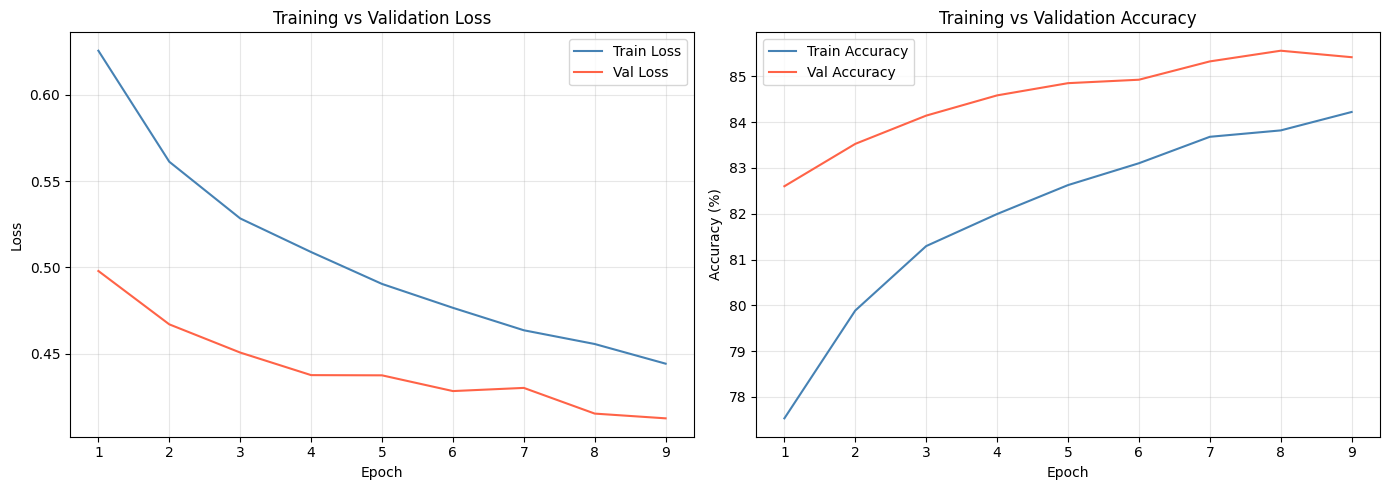

Plot saved as accuracy_loss_plot.png


In [16]:
# CELL 11 - plot training curves

# plotting loss and accuracy against epochs so I can see how training went
# if val loss goes up while train loss goes down that means overfitting

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Adjust epochs_range to match the actual number of completed epochs
epochs_range = range(1, len(train_loss_history) + 1)

# loss plot
ax1.plot(epochs_range, train_loss_history, label='Train Loss', color='steelblue')
ax1.plot(epochs_range, val_loss_history, label='Val Loss', color='tomato')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# accuracy plot
ax2.plot(epochs_range, train_acc_history, label='Train Accuracy', color='steelblue')
ax2.plot(epochs_range, val_acc_history, label='Val Accuracy', color='tomato')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_loss_plot.png', dpi=150)
plt.show()

print("Plot saved as accuracy_loss_plot.png")

In [17]:
# CELL 12 - evaluate on the full validation set one more time

model.eval()
correct = 0
total = 0

all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

final_val_acc = correct / total * 100
print(f"Final validation accuracy: {final_val_acc:.2f}%")

Final validation accuracy: 85.56%


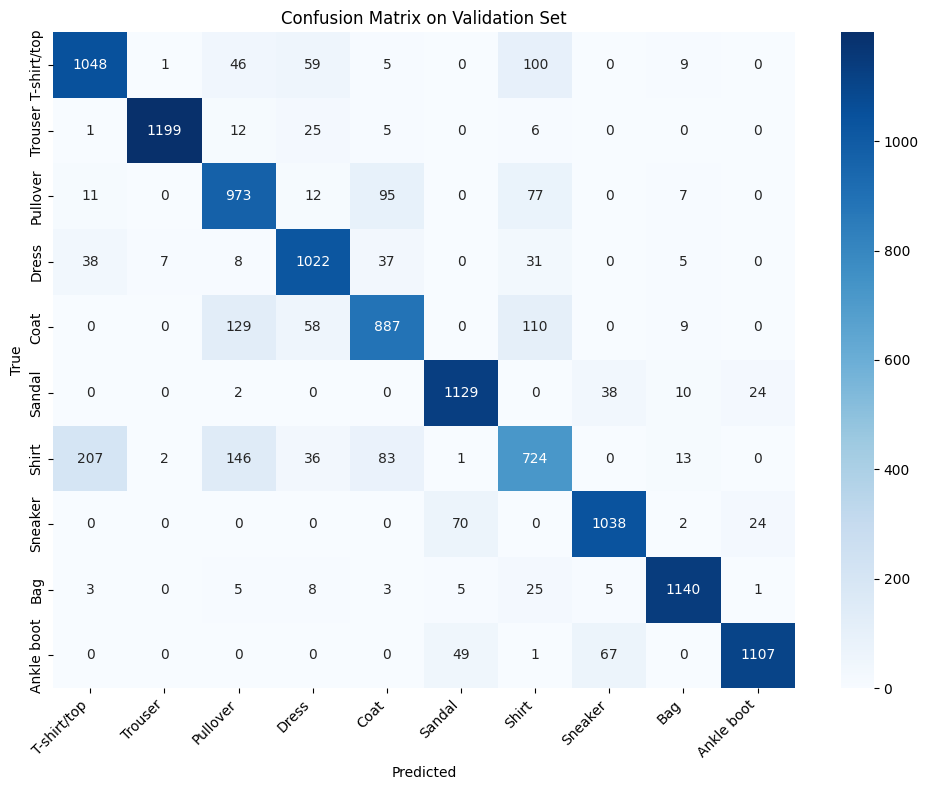


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.83      0.81      1268
     Trouser       0.99      0.96      0.98      1248
    Pullover       0.74      0.83      0.78      1175
       Dress       0.84      0.89      0.86      1148
        Coat       0.80      0.74      0.77      1193
      Sandal       0.90      0.94      0.92      1203
       Shirt       0.67      0.60      0.63      1212
     Sneaker       0.90      0.92      0.91      1134
         Bag       0.95      0.95      0.95      1195
  Ankle boot       0.96      0.90      0.93      1224

    accuracy                           0.86     12000
   macro avg       0.86      0.86      0.85     12000
weighted avg       0.86      0.86      0.85     12000



In [18]:
# CELL 13 - confusion matrix to see where the model makes mistakes

# a confusion matrix shows which classes the model gets mixed up
# rows are true labels, columns are predicted labels

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Validation Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# also printing a text report with precision, recall, F1 for each class
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=class_names))

In [19]:
# CELL 14 - save model weights using pickle

# the task specifically asks to save with Pickle
# I am saving both the weights and some metadata about the model

os.makedirs('saved_models', exist_ok=True)

model_data = {
    'model_state_dict': best_model_weights,
    'val_accuracy': best_val_accuracy,
    'class_names': class_names,
    'architecture': 'FashionNet with skip connection and dual branch'
}

with open('saved_models/fashion_net_weights.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model weights saved to saved_models/fashion_net_weights.pkl")

# also saving the full model state dict in PyTorch format as a backup
torch.save(best_model_weights, 'saved_models/fashion_net_state_dict.pth')
print("PyTorch state dict also saved as fashion_net_state_dict.pth")

Model weights saved to saved_models/fashion_net_weights.pkl
PyTorch state dict also saved as fashion_net_state_dict.pth


In [20]:
# CELL 15 - generate predictions on test set and create submission.csv

# the test set does not have labels so I just run it through the model
# and record what the model predicts for each image

model.eval()
test_predictions = []
image_ids = []
current_id = 0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        predicted_classes = outputs.argmax(dim=1)

        for pred in predicted_classes.cpu().numpy():
            test_predictions.append(pred)
            image_ids.append(current_id)
            current_id += 1

# create a dataframe with image id and predicted label
submission_df = pd.DataFrame({
    'image_id': image_ids,
    'predicted_label': test_predictions,
    'predicted_class': [class_names[p] for p in test_predictions]
})

submission_df.to_csv('submission.csv', index=False)
print("submission.csv saved with", len(submission_df), "predictions")
print(submission_df.head(10))

submission.csv saved with 10000 predictions
   image_id  predicted_label predicted_class
0         0                9      Ankle boot
1         1                2        Pullover
2         2                1         Trouser
3         3                1         Trouser
4         4                6           Shirt
5         5                1         Trouser
6         6                4            Coat
7         7                6           Shirt
8         8                5          Sandal
9         9                7         Sneaker


In [22]:
# CELL 16 - verify saved model by loading and testing it

# I want to make sure my saved weights actually load correctly
# this also shows how to use the model for inference

verify_model = FashionNet().to(device)

with open('saved_models/fashion_net_weights.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

verify_model.load_state_dict(loaded_data['model_state_dict'])
verify_model.eval()

# run one batch through the loaded model
sample_imgs, sample_lbls = next(iter(val_loader))
sample_imgs = sample_imgs.to(device)

with torch.no_grad():
    sample_outputs = verify_model(sample_imgs)
    sample_preds = sample_outputs.argmax(dim=1)

acc_check = (sample_preds == sample_lbls.to(device)).float().mean().item() * 100
print(f"Verification batch accuracy: {acc_check:.2f}%")
print("Model loads and runs correctly.")

Verification batch accuracy: 85.94%
Model loads and runs correctly.


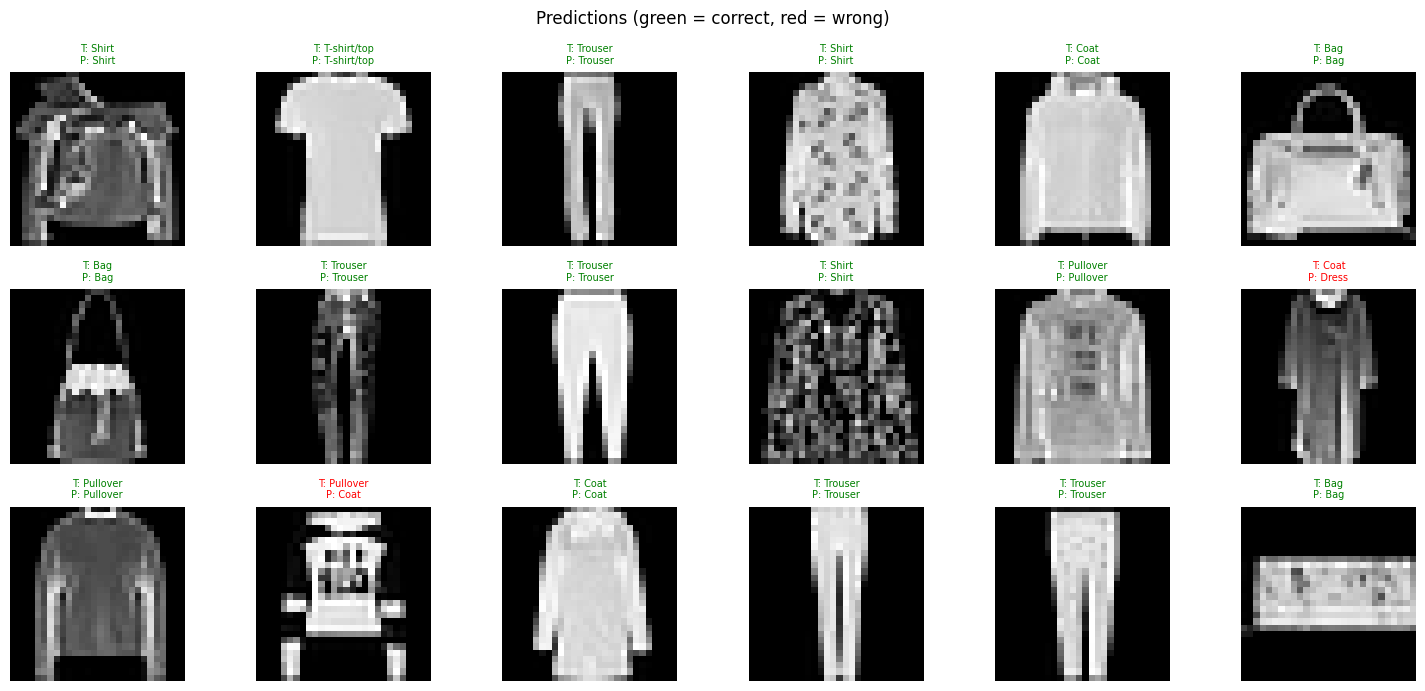

In [23]:
# CELL 17 - visualize some predictions

# showing a grid of test images with what the model predicted
# green title means correct, red means wrong

model.eval()
sample_imgs, sample_lbls = next(iter(val_loader))
sample_imgs_dev = sample_imgs.to(device)

with torch.no_grad():
    outputs = model(sample_imgs_dev)
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(3, 6, figsize=(15, 7))
for i, ax in enumerate(axes.flat):
    if i >= len(sample_imgs):
        break
    img = sample_imgs[i].squeeze().numpy()
    true_label = class_names[sample_lbls[i]]
    pred_label = class_names[preds[i]]
    color = 'green' if preds[i] == sample_lbls[i] else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=7)
    ax.axis('off')

plt.suptitle("Predictions (green = correct, red = wrong)", fontsize=12)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()